# RL Homework

In [4]:
import torch
from torch import nn, optim
import numpy as np
import matplotlib.pyplot as plt
import random
from tqdm.notebook import tqdm
import gymnasium as gym
#%matplotlib inline
#%config InlineRenderer.figure_format = 'retina'

In [5]:
device = 'cpu'
if torch.cuda.is_available():
    device = 'cuda:1'
elif torch.backends.mps.is_available():
    device = 'mps'
print(device)

cpu


In [6]:
env = gym.make("ALE/Frogger-v5")

In [7]:
env.observation_space

Box(0, 255, (210, 160, 3), uint8)

As in previous homework assignments, I've broken this down into three sections.

NOTE: Reinforcement learning often has pretty high variance, especially for the relatively simple algorithms we've looked at in this class. If your results look like there is some learning happening but it's pretty noisy or if you see rewards going up and then back down again, it may be worth just rerunning training to see what happens. Most likely if you don't get reasonable-looking results in 2-3 runs then something is wrong.

## Q Learning (C)

The basic version of this homework involves using deep Q learning to control the Acrobot. This is very similar to what we did in class on Monday. For this part of the homework you'll need to set up the `QNetwork` to approximate the Q function and finish the training code below. The `ReplayMemory` class is already complete. Remember that Q learning involves learnign an approximation $\hat{Q}$ to the optimal Q function according to the temporal difference loss

$$
L(\hat{Q}) = \sum_{(s, a, r, s') \in D} \left \| \hat{Q}(s, a) - \left ( r + \gamma \max_{a'} \hat{Q}(s', a') \right ) \right \|
$$

The way we do exploration in this version is a bit different from what we had in class. There we took three parameters, `eps_start`, `eps_end` and `eps_rate` and we took a random action with a probability that started at `eps_start` and then exponentially decayed toward `eps_end` at a rate controlled by `eps_rate`. For this homework, we'll use a simpler approach called $\varepsilon$-greedy exploration where we always take a random action with probability $\varepsilon$ and choose an action from our Q network with probability $(1-\varepsilon)$.

In [8]:
class QNetwork(nn.Module):

    def __init__(self, state_dim, num_actions):
        super().__init__()
        # Create a neural network model
        # self.model = nn.Sequential(
        #     nn.Linear(state_dim, 20),
        #     nn.ReLU(),
        #     nn.Linear(20, 20),
        #     nn.ReLU(),
        #     nn.Linear(20, num_actions)
        # )
        self.model = nn.Sequential(
            nn.Conv2d(3, 16, 8, stride=4),
            nn.ReLU(),
            nn.Conv2d(16, 32, 4, stride=2),
            nn.ReLU(),
            nn.Conv2d(32, 64, 3, stride=2),
            nn.ReLU(),
            nn.Conv2d(64, 64, 3, stride=2),
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(960, num_actions)
        )

    def forward(self, x):
        # Run your model on x. This should return a Q value for each action.
        return self.model(x)
        


class ReplayMemory:

    def __init__(self, cap, evict_oldest=False):
        self.capacity = cap
        self.data = []
        self.evict_oldest = evict_oldest
        if self.evict_oldest:
            self.oldest = 0

    def push(self, state, action, reward, nstate, term):
        if len(self.data) < self.capacity:
            self.data.append((state, action, reward, nstate, term))
        else:
            if self.evict_oldest:
                idx = self.oldest
                self.oldest = (self.oldest + 1) % self.capacity
            else:
                idx = random.randint(0, self.capacity - 1)
            self.data[idx] = (state, action, reward, nstate, term)

    def sample(self, batch_size):
        return random.sample(self.data, batch_size)

    def __len__(self):
        return len(self.data)

    def empty(self):
        self.data = []
        if self.evict_oldest:
            self.oldest = 0

In [14]:
def train_q_learning(env, gamma=0.99, lr=2.5e-4, tau=0.01, batch_size=32, num_interactions=10000, eps=0.1, double=False, linear_eps_decay = 1000000):
    actionspace = 5
    statespace = (210,160)
    policy_network = QNetwork(statespace, actionspace).to(device)
    target_network = QNetwork(statespace, actionspace).to(device)
    target_network.load_state_dict(policy_network.state_dict())

    replay_buffer = ReplayMemory(1000000)

    opt = optim.Adam(policy_network.parameters(), lr=lr)
    loss = nn.SmoothL1Loss()
    rng = np.random.default_rng()
    last_save = 0
    state, _ = env.reset()
    # state = state.flatten()
    # print(state.shape)
    # print(torch.tensor(state, dtype = torch.float).is_contiguous(memory_format=torch.channels_last))
    state = state.transpose(2, 0, 1) 
    # plt.imshow([0,:,:])
    eps_goal = eps
    ep_r = 0
    ep_rewards = []
    for i in tqdm(range(num_interactions)):
        
        # Choose a random action with probability eps, otherwise take the best
        # action according to the policy network.
        if i <= linear_eps_decay:
            eps = 1 - i * ((1 - eps_goal) / linear_eps_decay)
        if rng.random() <= eps:
            action = rng.integers(0, actionspace)
        else:
            # print(torch.tensor(state, dtype=torch.float).unsqueeze(dim=0).shape)
            action = policy_network(torch.tensor(state, dtype=torch.float, device = device).unsqueeze(dim=0)).argmax()
        # Take a step in the environment, add the transition to the replay
        # buffer, and add the reward to ep_r
        # print(policy_network(torch.tensor(state), dtype=torch.float)).shape)
        # print(action)
        nstate, reward, term, trunc, _ = env.step(action)
        nstate = nstate.transpose(2, 0, 1)
        replay_buffer.push(state, action, reward, nstate, term)
        state = nstate
        ep_r += reward
        if len(replay_buffer) >= batch_size:
            batch = replay_buffer.sample(batch_size)
            st_batch, act_batch, r_batch, nst_batch, t_batch = zip(*batch)
            st_batch = torch.tensor(np.array(st_batch), device = device).float()
            act_batch = torch.tensor(np.array(act_batch), device = device).unsqueeze(dim=1)
            r_batch = torch.tensor(np.array(r_batch), device = device).float()
            nst_batch = torch.tensor(np.array(nst_batch), device = device).float()
            t_batch = torch.tensor(np.array(t_batch), device = device)

            # Evaluate the policy network on st_batch and choose Q values
            # corresponding to actions in act_batch. These is your predicted
            # Q values.
            pred_vals = policy_network(st_batch).gather(1, act_batch).squeeze()

            # Evaluate the target network on nst_batch and take the maximum
            # over actions. For every element where t_batch is True, set this
            # value to zero.
                    
            # if sarsa == True:
            #     nact = policy_network(nst_batch).argmax(dim = 1)

            #     index = torch.rand(nact.size(dim=0))
            #     index[index <= eps] = 1
            #     index[index != 1 ] = 0
            #     index = index.bool()
            #     nact[index] = torch.tensor(rng.integers(0, env.num_actions, size = index[index == True].size(dim=0)))
            #     nact = nact.unsqueeze(dim = 1)
 
            #     pred_next_vals = target_network(nst_batch).gather(1, nact).squeeze()
            # else:
            if double == False:
                pred_next_vals = target_network(nst_batch).max(dim=1).values
            else:
                pred_next_vals = target_network(nst_batch).gather(1, policy_network(nst_batch).argmax(dim=1).unsqueeze(dim=1)).squeeze()
            pred_next_vals[t_batch] = 0

            # Compute the expected Q value (the right hand side of our loss
            # above) using the target network values you just computed and
            # r_batch.
            expected_q = r_batch + gamma * pred_next_vals

            # Apply loss to your predicted Q values and expected Q values.
            loss_val = loss(pred_vals, expected_q)

            # Take an optimization step
            opt.zero_grad()
            loss_val.backward()
            opt.step()

        p_state_dict = policy_network.state_dict()
        t_state_dict = target_network.state_dict()
        for key in p_state_dict:
            t_state_dict[key] = p_state_dict[key] * tau + t_state_dict[key] * (1 - tau)
        target_network.load_state_dict(t_state_dict)
        
        last_save += 1
        if term or trunc:
            ep_rewards.append(ep_r)
            if last_save >= 1000000:
                torch.save(policy_network.state_dict(), "./models/model" + str(ep_r) + ".pt")
                last_save = 0
            state, _ = env.reset()
            state = state.transpose(2, 0, 1)
            ep_r = 0 
        
    return policy_network, ep_rewards

In [15]:
q_policy, q_returns = train_q_learning(env, lr=2.5e-4, num_interactions=10000)

  0%|          | 0/10000 [00:00<?, ?it/s]

KeyboardInterrupt: 

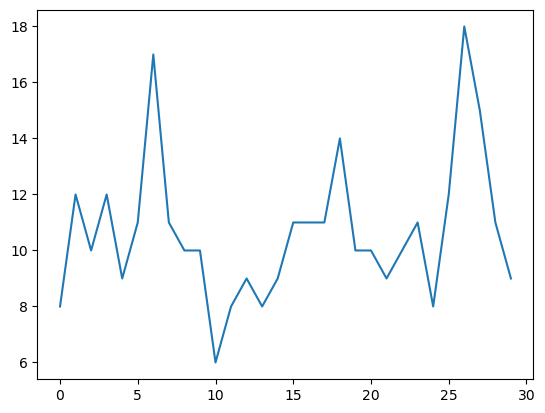

In [230]:
plt.plot(q_returns)
plt.show()

In [231]:
torch.save(q_policy.state_dict(), "./qmodel2.pt")

In [232]:
print(q_policy)

QNetwork(
  (model): Sequential(
    (0): Conv2d(3, 16, kernel_size=(8, 8), stride=(4, 4))
    (1): ReLU()
    (2): Conv2d(16, 32, kernel_size=(4, 4), stride=(2, 2))
    (3): ReLU()
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2))
    (5): ReLU()
    (6): Conv2d(64, 64, kernel_size=(3, 3), stride=(2, 2))
    (7): ReLU()
    (8): Flatten(start_dim=1, end_dim=-1)
    (9): Linear(in_features=960, out_features=5, bias=True)
  )
)


In [235]:
q_policy = QNetwork(10,5)
q_policy.load_state_dict(torch.load("./qmodel2.pt"))
q_policy.eval()

QNetwork(
  (model): Sequential(
    (0): Conv2d(3, 16, kernel_size=(8, 8), stride=(4, 4))
    (1): ReLU()
    (2): Conv2d(16, 32, kernel_size=(4, 4), stride=(2, 2))
    (3): ReLU()
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(2, 2))
    (5): ReLU()
    (6): Conv2d(64, 64, kernel_size=(3, 3), stride=(2, 2))
    (7): ReLU()
    (8): Flatten(start_dim=1, end_dim=-1)
    (9): Linear(in_features=960, out_features=5, bias=True)
  )
)

In [249]:
envObserve = gym.make("ALE/Frogger-v5",frameskip = 1, repeat_action_probability = 0, render_mode = "human")

state, info = envObserve.reset()
state = state.transpose(2, 0, 1)
print(state.shape)
for _ in range(10000):
    action = q_policy(torch.tensor(state, dtype=torch.float).unsqueeze(dim=0)).argmax()  # agent policy that uses the observation and info
    state, reward, terminated, truncated, info = envObserve.step(action)
    state = state.transpose(2, 0, 1)
    if terminated or truncated:
        observation, info = envObserve.reset()

(3, 210, 160)


In [250]:
envObserve.spec

EnvSpec(id='ALE/Frogger-v5', entry_point='shimmy.atari_env:AtariEnv', reward_threshold=None, nondeterministic=False, max_episode_steps=None, order_enforce=True, autoreset=False, disable_env_checker=False, apply_api_compatibility=False, kwargs={'game': 'frogger', 'obs_type': 'rgb', 'repeat_action_probability': 0, 'full_action_space': False, 'frameskip': 1, 'max_num_frames_per_episode': 108000, 'render_mode': 'human'}, namespace='ALE', name='Frogger', version=5, additional_wrappers=(), vector_entry_point=None)

In [251]:
envObserve.close()

In [16]:
d_policy, d_returns = train_q_learning(env, lr=2.5e-4, num_interactions=10000, double = True)

  0%|          | 0/10000 [00:00<?, ?it/s]

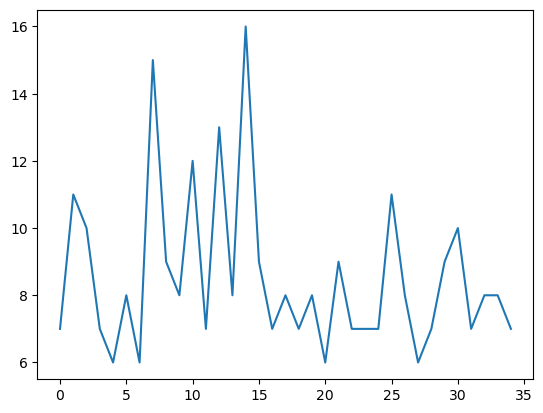

In [17]:
plt.plot(d_returns)
plt.show()

In [37]:
torch.save(d_policy.state_dict(), "./dmodel.pt")

In [252]:
d_policy.eval()

QNetwork(
  (model): Sequential(
    (0): Linear(in_features=100800, out_features=20, bias=True)
    (1): ReLU()
    (2): Linear(in_features=20, out_features=20, bias=True)
    (3): ReLU()
    (4): Linear(in_features=20, out_features=5, bias=True)
  )
)

In [52]:
envObserve2 = gym.make("ALE/Frogger-v5", render_mode = "human")

state, info = envObserve2.reset()

for _ in range(10000):
    actions = d_policy(torch.tensor(state, dtype=torch.float).flatten())
    action = actions.argmax()  # agent policy that uses the observation and info
    state, reward, terminated, truncated, info = envObserve2.step(action)

    if terminated or truncated:
        state, info = envObserve2.reset()

envObserve2.close()

tensor([4.5433, 4.5594, 4.8267, 4.4189, 4.4860], grad_fn=<ViewBackward0>)
tensor(2)
tensor([4.7000, 4.7061, 4.9825, 4.5673, 4.6389], grad_fn=<ViewBackward0>)
tensor(2)
tensor([4.7044, 4.7102, 4.9869, 4.5715, 4.6432], grad_fn=<ViewBackward0>)
tensor(2)
tensor([4.6287, 4.6394, 4.9117, 4.4999, 4.5693], grad_fn=<ViewBackward0>)
tensor(2)
tensor([4.5021, 4.5208, 4.7857, 4.3798, 4.4457], grad_fn=<ViewBackward0>)
tensor(2)
tensor([4.4385, 4.4612, 4.7225, 4.3196, 4.3836], grad_fn=<ViewBackward0>)
tensor(2)
tensor([4.4437, 4.4661, 4.7276, 4.3245, 4.3886], grad_fn=<ViewBackward0>)
tensor(2)
tensor([4.4763, 4.4966, 4.7601, 4.3554, 4.4205], grad_fn=<ViewBackward0>)
tensor(2)
tensor([4.5225, 4.5399, 4.8060, 4.3992, 4.4656], grad_fn=<ViewBackward0>)
tensor(2)
tensor([4.5359, 4.5524, 4.8193, 4.4119, 4.4787], grad_fn=<ViewBackward0>)
tensor(2)
tensor([4.4947, 4.5139, 4.7784, 4.3729, 4.4385], grad_fn=<ViewBackward0>)
tensor(2)
tensor([4.5837, 4.5972, 4.8668, 4.4571, 4.5253], grad_fn=<ViewBackward0>)
te

KeyboardInterrupt: 

In [41]:
envObserve2.close()

## SARSA (B)

In this section we'll make a slight alteration to the Q learning function above in order to implement SARSA, another classic reinforcement learning algorithm. SARSA is very similar to Q learning except that it uses the _policy_ Q value estimate rather than the _optimal_ Q value estimate. Concretely, this means Q learning uses the update loss

$$
\left \| \hat{Q}(s, a) - \left ( r + \gamma \max_{a'} \hat{Q}(s', a') \right ) \right \|
$$

whereas SARSA first selects an action $a'$ using the same policy we're using for exploration (that is, it uses the $\epsilon$-greedy scheme) then uses the update rule

$$
\left \| \hat{Q}(s, a) - \left ( r + \gamma \hat{Q}(s', a') \right ) \right \|
$$

The difference between the two is only how $a'$ is selected. For SARSA we use the same $\varepsilon$-greedy policy we use to choose actions to take in the environment, for Q learning we use the true greedy action without any random chance. Modify the Q learning function above so that if the `sarsa` argument is set to true, it uses SARSA and otherwise it uses Q learning. Concretely, this means that rather than taking a maximum over actions on the target Q values of `nst_batch`, you should get a batch of actions using the $\varepsilon$-greedy strategy and use those actions to index into the target Q values of `nst_batch`. (This is similar to how you use the actions `act_batch` to index into the policy Q values of `st_batch` in Q learning.)

In [1]:
def train_sarsa_learning(env, gamma=0.99, lr=1e-3, tau=0.05, batch_size=128, num_interactions=10000, eps=0.1, double=False):
    actionspace = 5
    statespace = (210,160)
    policy_network = QNetwork(statespace, actionspace)
    target_network = QNetwork(statespace, actionspace)
    target_network.load_state_dict(policy_network.state_dict())

    replay_buffer = ReplayMemory(10000)

    opt = optim.Adam(policy_network.parameters(), lr=lr)
    loss = nn.SmoothL1Loss()
    rng = np.random.default_rng()

    state, _ = env.reset()
    # state = state.flatten()
    # print(state.shape)
    # print(torch.tensor(state, dtype = torch.float).is_contiguous(memory_format=torch.channels_last))
    state = state.transpose(2, 0, 1) 
    # plt.imshow([0,:,:])
    ep_r = 0
    ep_rewards = []
    for i in tqdm(range(num_interactions)):
        
        # Choose a random action with probability eps, otherwise take the best
        # action according to the policy network.
        if rng.random() <= eps:
            action = rng.integers(0, actionspace)
        else:
            # print(torch.tensor(state, dtype=torch.float).unsqueeze(dim=0).shape)
            action = policy_network(torch.tensor(state, dtype=torch.float).unsqueeze(dim=0)).argmax()
        # Take a step in the environment, add the transition to the replay
        # buffer, and add the reward to ep_r
        # print(policy_network(torch.tensor(state), dtype=torch.float)).shape)
        # print(action)
        nstate, reward, term, trunc, _ = env.step(action)
        nstate = nstate.transpose(2, 0, 1) 
        replay_buffer.push(state, action, reward, nstate, term)
        state = nstate
        ep_r += reward
        if len(replay_buffer) >= batch_size:
            batch = replay_buffer.sample(batch_size)
            st_batch, act_batch, r_batch, nst_batch, t_batch = zip(*batch)
            st_batch = torch.tensor(np.array(st_batch)).float()
            act_batch = torch.tensor(np.array(act_batch)).unsqueeze(dim=1)
            r_batch = torch.tensor(np.array(r_batch)).float()
            nst_batch = torch.tensor(np.array(nst_batch)).float()
            t_batch = torch.tensor(np.array(t_batch))

            # Evaluate the policy network on st_batch and choose Q values
            # corresponding to actions in act_batch. These is your predicted
            # Q values.
            pred_vals = policy_network(st_batch).gather(1, act_batch).squeeze()

            # Evaluate the target network on nst_batch and take the maximum
            # over actions. For every element where t_batch is True, set this
            # value to zero.
                    
            # if sarsa == True:
            #     nact = policy_network(nst_batch).argmax(dim = 1)

            #     index = torch.rand(nact.size(dim=0))
            #     index[index <= eps] = 1
            #     index[index != 1 ] = 0
            #     index = index.bool()
            #     nact[index] = torch.tensor(rng.integers(0, env.num_actions, size = index[index == True].size(dim=0)))
            #     nact = nact.unsqueeze(dim = 1)
 
            #     pred_next_vals = target_network(nst_batch).gather(1, nact).squeeze()
            # else:
            if double == False:
                pred_next_vals = target_network(nst_batch).max(dim=1).values
            else:
                expected_value = target_network
                pred_next_vals = target_network(nst_batch).gather(1, policy_network(nst_batch).argmax(dim=1).unsqueeze(dim=1)).squeeze()
            pred_next_vals[t_batch] = 0

            # Compute the expected Q value (the right hand side of our loss
            # above) using the target network values you just computed and
            # r_batch.
            expected_q = r_batch + gamma * pred_next_vals

            # Apply loss to your predicted Q values and expected Q values.
            loss_val = loss(pred_vals, expected_q)

            # Take an optimization step
            opt.zero_grad()
            loss_val.backward()
            opt.step()

        p_state_dict = policy_network.state_dict()
        t_state_dict = target_network.state_dict()
        for key in p_state_dict:
            t_state_dict[key] = p_state_dict[key] * tau + t_state_dict[key] * (1 - tau)
        target_network.load_state_dict(t_state_dict)

        if term or trunc:
            ep_rewards.append(ep_r)
            torch.save(policy_network.state_dict(), "./models/model" + str(ep_r) + ".pt")
            state, _ = env.reset()
            state = state.transpose(2, 0, 1)
            ep_r = 0

    return policy_network, ep_rewards

## Actor-Critic (A)

In this section we'll solve the same environment using an actor-critic algorithm rather than Q-learning. For this you'll need to define a policy network and a critic network then fill in the training code below. Actor-critic algorithms come in different flavors, but for this homework we'll optimize the critic $\hat{V}$ to minimize

$$
L(\hat{V}) = \sum_{(s, a, r, s') \in D} \left \| \hat{V}(s) - \left ( r + \gamma \hat{V}(s') \right ) \right \|
$$

and optimize the policy $\pi$ to maximize

$$
J(\pi) = \sum_{(s, a, r, s') \in D} \left ( r + \gamma \hat{V}(s') - \hat{V}(s) \right ) \log \pi(a \mid s)
$$

To make things a bit easier, we'll use a single PyTorch optimizer object trained on the loss $\beta L(\hat{V}) - J(\pi)$ where $\beta$ is a hyperparameter controlling how much relative weight to give the critic loss. You shouldn't need to tune $\beta$ for this homework.

It's also often useful to explicitly encourage exploration by giving the policy a reward based on it's entropy. Mathematically,

$$
J(\pi) = \sum_{(s, a, r, s') \in D} \left ( r + \gamma \hat{V}(s') - \hat{V}(s) \right ) \log \pi(a \mid s) + \alpha H \left ( \pi(\cdot \mid s) \right )
$$

where $H$ measures entropy. This is optional for this homework but may help you get better performance.

In order to make training feasible, you should have your policy network output a PyTorch distribution object (available in `torch.distributions`). Distribution objects have a `.log_prob(a)` method which can tell you the probability of selecting action `a` and an `.entropy()` method which gives you their entropy.

In [100]:
class Policy(nn.Module):

    def __init__(self, state_dim, num_actions):
        super().__init__()
        # set up self.model. This should be a neural network which outputs
        # logits for each action.
        self.model = nn.Sequential(
            nn.Linear(state_dim, 20),
            nn.ReLU(),
            nn.Linear(20, 20),
            nn.ReLU(),
            nn.Linear(20, num_actions)
        )


    def forward(self, x):
        logits = self.model(x)
        return torch.distributions.Categorical(logits=logits)


class Critic(nn.Module):

    def __init__(self, state_dim):
        super().__init__()
        # Set up self.model. This should be a neural network which outputs
        # a single number.
        self.model = nn.Sequential(
            nn.Linear(state_dim, 20),
            nn.ReLU(),
            nn.Linear(20, 20),
            nn.ReLU(),
            nn.Linear(20, 1))

    def forward(self, x):
        return self.model(x).squeeze(dim=-1)

In [101]:
def actor_critic(env, critic_weight=0.5, entropy_weight=0.2, lr=1e-3, num_interactions=10000, gamma=0.99, update_interval=10, alpha = 0.2, beta = 1):

    actor = Policy(env.state_dim, env.num_actions)
    critic = Critic(env.state_dim)

    opt = optim.Adam(list(actor.parameters()) + list(critic.parameters()), lr=lr)
    critic_loss_func = nn.SmoothL1Loss()

    replay_buffer = ReplayMemory(update_interval)

    state, _ = env.reset()
    ep_rew = 0
    ep_rewards = []

    for step_count in tqdm(range(num_interactions)):
        
        # Choose an action for the environment. We're no longer using the
        # epsilon-greedy approach since our policy is now stochastic. Instead
        # you should get a distribution by calling your policy network then use
        # the distribution's .sample() method to choose an action.
        distrib = actor(torch.tensor(state, dtype=torch.float))
        action = distrib.sample()
        action_log_prob = distrib.log_prob(action)
        nstate, reward, term, trunc, _ = env.step(action.detach().numpy())
        replay_buffer.push(state, action, reward, nstate, term)
        state = nstate
        ep_rew += reward
        
        if (step_count + 1) % update_interval == 0:
            batch = replay_buffer.sample(update_interval)
            st_batch, act_batch, r_batch, nst_batch, t_batch = zip(*batch)
            st_batch = torch.tensor(np.array(st_batch)).float()
            act_batch = torch.tensor(np.array(act_batch))
            r_batch = torch.tensor(np.array(r_batch)).float()
            nst_batch = torch.tensor(np.array(nst_batch)).float()
            t_batch = torch.tensor(np.array(t_batch))
            replay_buffer.empty()
        
            # Compute the total loss L(V) - J(\pi).
            critic_reward = critic(nst_batch)
            critic_reward[t_batch] = 0
            reward = r_batch + gamma * critic_reward
            pred_reward = critic(st_batch)
            critic_loss = critic_loss_func(pred_reward, reward)

            policyDistrib = actor(st_batch)
            actor_adv = torch.sum((reward.detach() - pred_reward.detach()) * policyDistrib.log_prob(act_batch) + alpha * policyDistrib.entropy())

            totalLoss = beta * critic_loss - actor_adv
            #print(totalLoss)
            opt.zero_grad()
            totalLoss.backward()
            opt.step()
            
            # You can use actor(st_batch) to get the policy action distribution
            # for each state then call .log_prob(act_batch) on those values to
            # get log \pi(a | s).

            # If you want to add entropy weighting, you can call .entropy() on
            # the distribution.

            # Take a gradient step. Since we put everything together into one
            # optimizer, this is just like the gradient steps we've seen before

        if term or trunc:
            state, _ = env.reset()
            ep_rewards.append(ep_rew)
            ep_rew = 0

    return actor, ep_rewards

In [102]:
env = AcrobotEnv()
ac_policy, ac_returns = actor_critic(env, num_interactions=100000, entropy_weight=0.2)

  0%|          | 0/100000 [00:00<?, ?it/s]

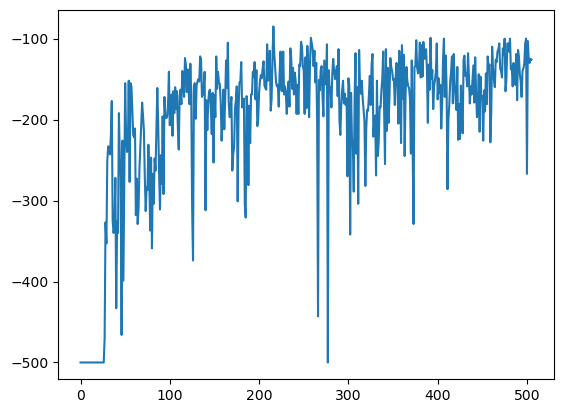

In [103]:
plt.plot(ac_returns)
plt.show()